# Pembangkitan Data Sintetis V2 (Synthetic Data Generation V2)

Notebook ini menggunakan pendekatan **Seasonal Decomposition + Residual Resampling** untuk membangkitkan data sintetis deret waktu yang mempertahankan tren, musiman, dan kontinuitas temporal dari data asli, sekaligus memperluas *timeline* dan menyuntikkan variasi stokastik terkendali.

**Perbedaan utama dari V1:**
- V1 menggunakan `df.sample(replace=True)` yang hanya menebalkan volume tanpa menambah observasi temporal baru.
- V2 mengekstrapolasi deret waktu ke masa depan dengan dekomposisi musiman dan *residual resampling*, menciptakan hari-hari baru yang belum pernah dilihat model.

In [13]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 150
np.random.seed(42)

# Output directories
os.makedirs('data/generated_v2/figures', exist_ok=True)

## Memuat dan Menyiapkan Data Asli

=== Data Asli ===
Rentang Waktu: 2015-01-01 s.d. 2018-01-31
Jumlah Observasi Harian: 1127
Rata-rata Permintaan Harian: 340.80
Std Permintaan Harian: 101.54


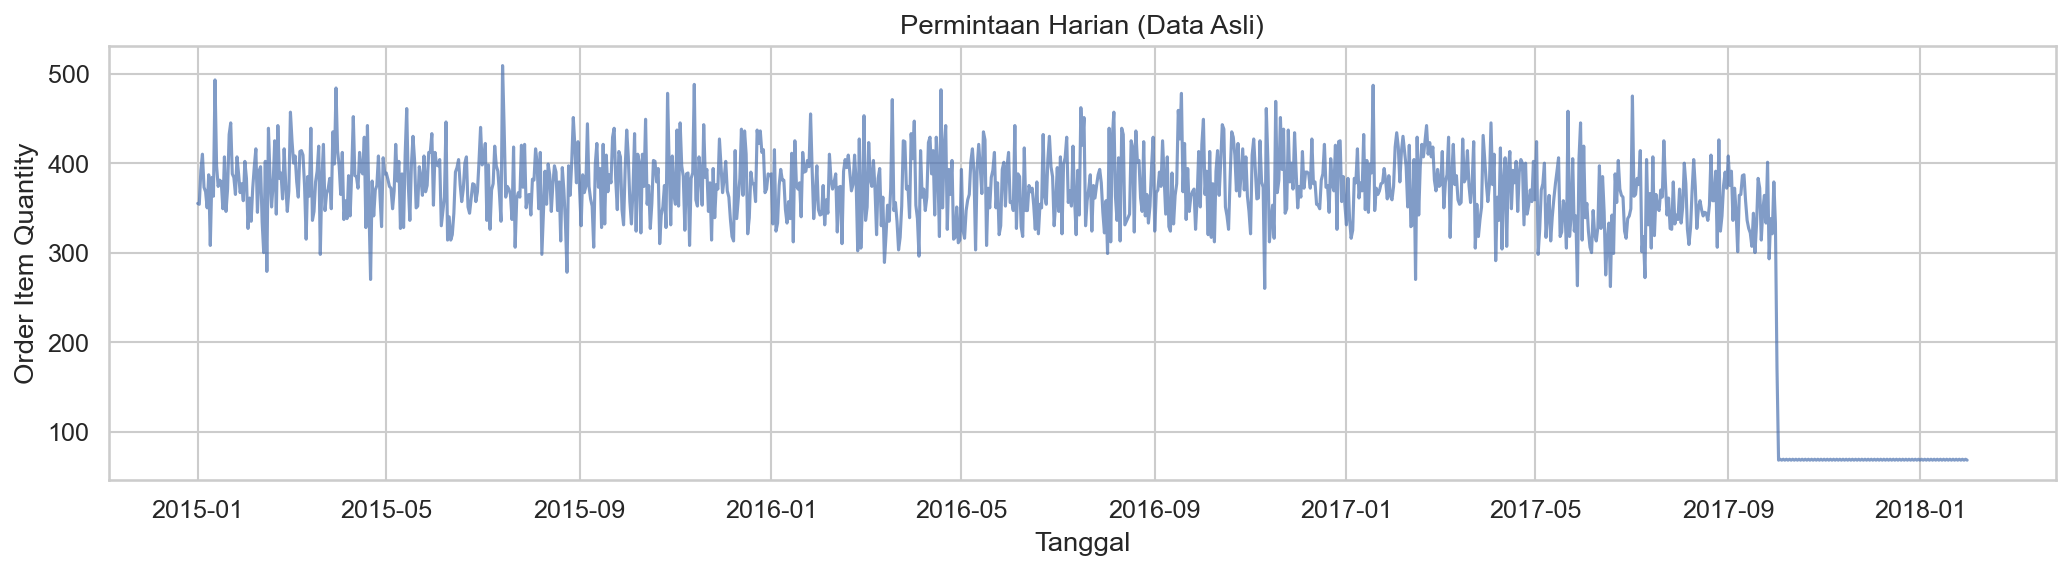

In [14]:
# Load dataset
df = pd.read_csv('data/processed/cold_chain_data.csv', parse_dates=['order date (DateOrders)'])
df = df.sort_values('order date (DateOrders)')

# Aggregate daily demand
daily = df.set_index('order date (DateOrders)')['Order Item Quantity'].resample('D').sum()
daily = daily.fillna(0)

print(f"=== Data Asli ===")
print(f"Rentang Waktu: {daily.index.min().date()} s.d. {daily.index.max().date()}")
print(f"Jumlah Observasi Harian: {len(daily)}")
print(f"Rata-rata Permintaan Harian: {daily.mean():.2f}")
print(f"Std Permintaan Harian: {daily.std():.2f}")

plt.figure(figsize=(14, 4))
plt.plot(daily.index, daily.values, alpha=0.7)
plt.title('Permintaan Harian (Data Asli)')
plt.xlabel('Tanggal')
plt.ylabel('Order Item Quantity')
plt.tight_layout()
plt.show()

## Dekomposisi Musiman (Seasonal Decomposition)

Mengurai deret waktu menjadi tiga komponen:
1. **Tren (Trend):** Pergerakan jangka panjang.
2. **Musiman (Seasonal):** Pola berulang.
3. **Residual:** Fluktuasi acak yang tersisa.

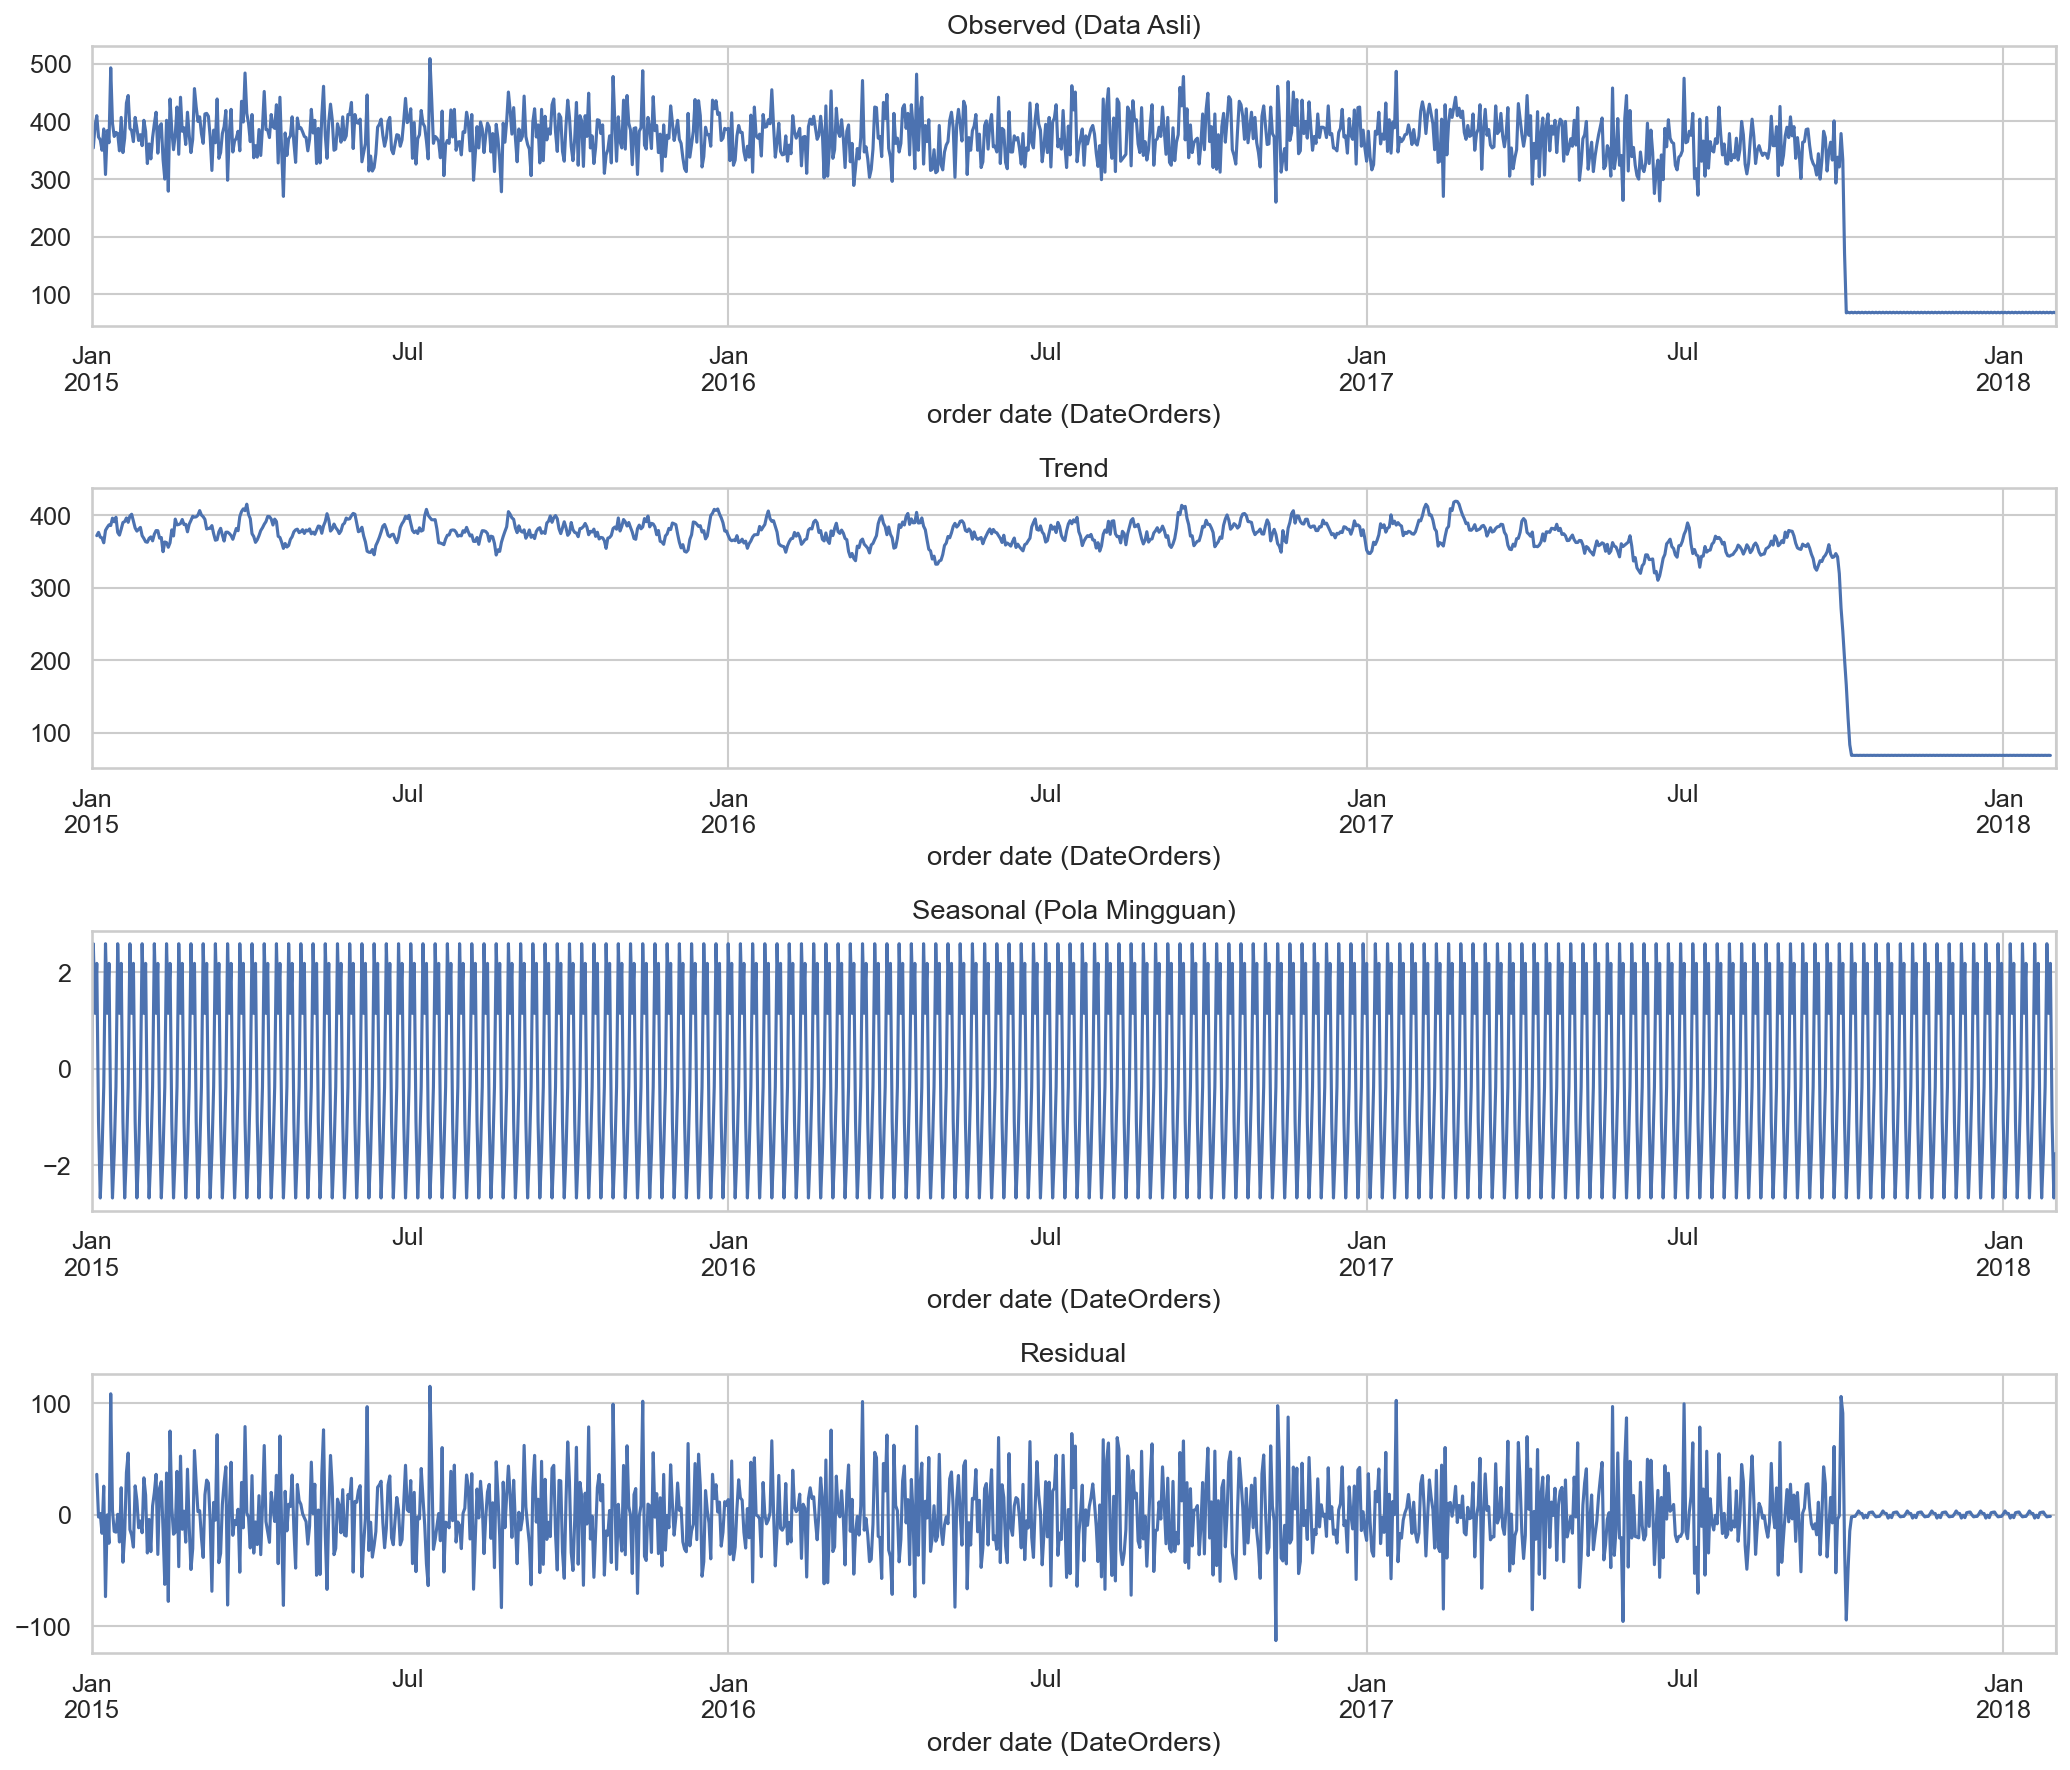

Komponen Trend: mean=341.44, std=94.85
Komponen Seasonal: mean=0.00, std=1.86
Komponen Residual: mean=0.01, std=33.15


In [15]:
# Use additive decomposition with period=365 (yearly seasonality)
# For shorter periods, use period=7 (weekly)
decomposition = seasonal_decompose(daily, model='additive', period=7)

fig, axes = plt.subplots(4, 1, figsize=(14, 12))
decomposition.observed.plot(ax=axes[0], title='Observed (Data Asli)')
decomposition.trend.plot(ax=axes[1], title='Trend')
decomposition.seasonal.plot(ax=axes[2], title='Seasonal (Pola Mingguan)')
decomposition.resid.plot(ax=axes[3], title='Residual')
plt.tight_layout()
plt.show()

trend = decomposition.trend.dropna()
seasonal = decomposition.seasonal
resid = decomposition.resid.dropna()

print(f"Komponen Trend: mean={trend.mean():.2f}, std={trend.std():.2f}")
print(f"Komponen Seasonal: mean={seasonal.mean():.2f}, std={seasonal.std():.2f}")
print(f"Komponen Residual: mean={resid.mean():.2f}, std={resid.std():.2f}")

## Strategi Pembangkitan Data Sintetis

Metode: **Trend Extrapolation + Seasonal Tiling + Residual Resampling**

1. **Tren:** Mengekstrapolasi tren menggunakan regresi polinomial dari data historis.
2. **Musiman:** Mengulangi (tile) pola musiman mingguan ke timeline yang diperpanjang.
3. **Residual:** Melakukan *block bootstrap* dari residual asli untuk mempertahankan struktur autokorelasi.
4. **Rekonstruksi:** `Synthetic = Trend + Seasonal + Resampled_Residual`

### Tiga Skenario:
- **Skenario A (Normal):** Variasi residual Â±1x asli.
- **Skenario B (Moderate Volatility):** Variasi residual Â±1.5x asli + 1 shock event.
- **Skenario C (High Volatility):** Variasi residual Â±2x asli + 2 shock events.

Timeline diperluas: 2015-01-01 s.d. 2019-01-31
Total observasi harian sintetis: 1492


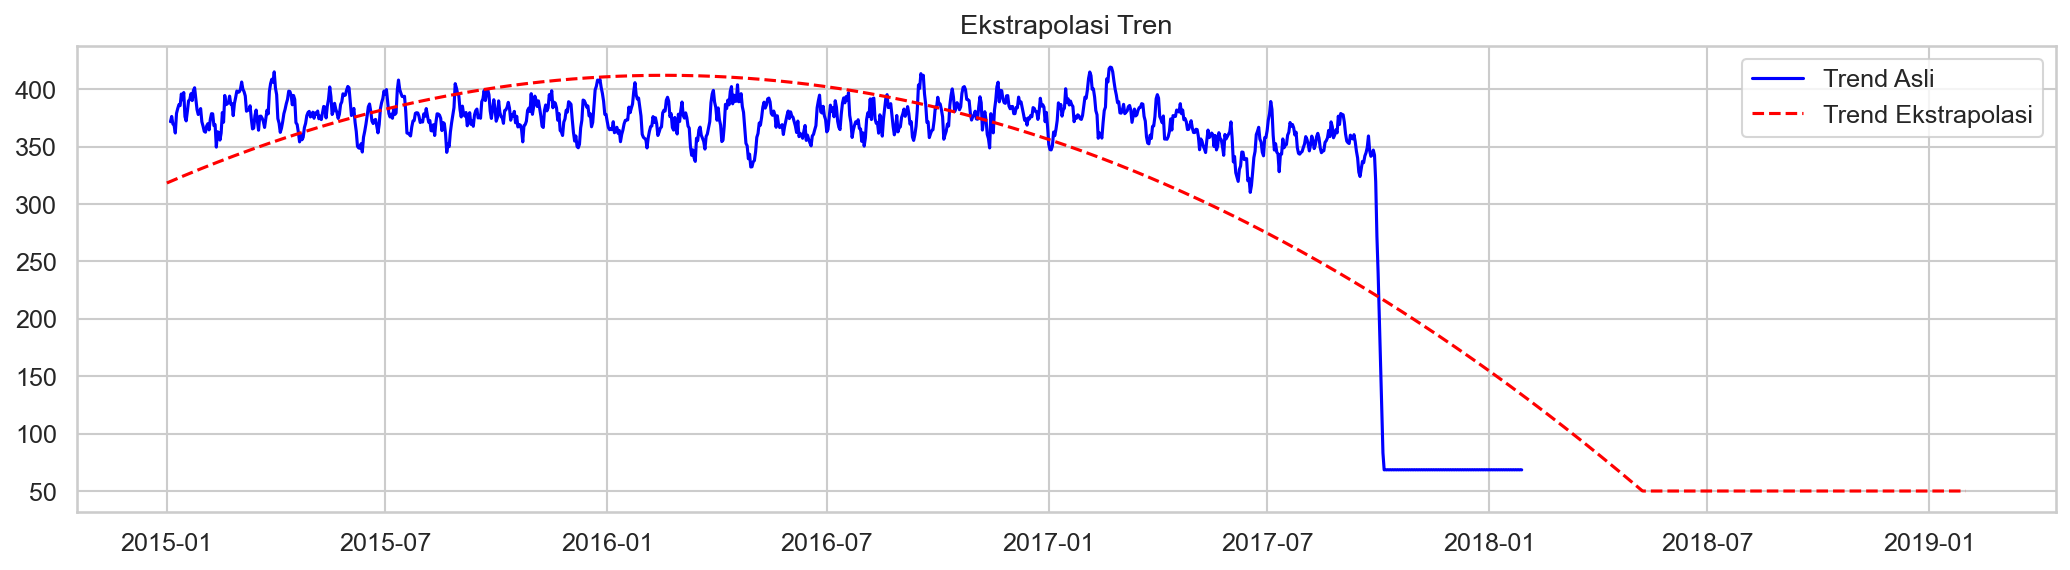

In [16]:
# === STEP 1: Trend Extrapolation ===
# Use polynomial regression on the trend component
trend_clean = trend.dropna()
x = np.arange(len(trend_clean))
# Fit degree-2 polynomial to capture the decline
poly_coeffs = np.polyfit(x, trend_clean.values, deg=2)
poly_fn = np.poly1d(poly_coeffs)

# Extend timeline: add 365 days beyond original end date
original_end = daily.index.max()
extension_days = 365
future_dates = pd.date_range(start=original_end + pd.Timedelta(days=1), periods=extension_days, freq='D')

# Total synthetic timeline = original + extension
full_dates = daily.index.append(future_dates)
n_total = len(full_dates)

# Extrapolate trend for full timeline
x_full = np.arange(n_total)
# Offset so original part aligns
offset = len(daily) - len(trend_clean)
x_trend_full = x_full - offset
trend_full = poly_fn(x_trend_full)

# Clamp trend to realistic range (don't let it go negative or explode)
trend_full = np.clip(trend_full, 50, daily.max() * 1.5)

print(f"Timeline diperluas: {full_dates[0].date()} s.d. {full_dates[-1].date()}")
print(f"Total observasi harian sintetis: {n_total}")

plt.figure(figsize=(14, 4))
plt.plot(trend_clean.index, trend_clean.values, label='Trend Asli', color='blue')
plt.plot(full_dates, trend_full, label='Trend Ekstrapolasi', color='red', linestyle='--')
plt.title('Ekstrapolasi Tren')
plt.legend()
plt.tight_layout()
plt.show()

In [17]:
# === STEP 2: Seasonal Tiling ===
# Tile the weekly seasonal pattern across the full timeline
seasonal_pattern = seasonal.values[:7]  # One week cycle
seasonal_full = np.tile(seasonal_pattern, n_total // 7 + 1)[:n_total]

print(f"Pola musiman mingguan: {seasonal_pattern.round(2)}")

# === STEP 3: Residual Block Bootstrap ===
resid_clean = resid.dropna().values
block_size = 7  # Weekly blocks to preserve autocorrelation

def block_bootstrap_residuals(residuals, target_length, block_size, scale=1.0):
    """Block bootstrap resampling of residuals."""
    n_blocks = len(residuals) // block_size
    blocks = [residuals[i*block_size:(i+1)*block_size] for i in range(n_blocks)]
    
    resampled = []
    while len(resampled) < target_length:
        block = blocks[np.random.randint(0, len(blocks))]
        resampled.extend(block * scale)
    
    return np.array(resampled[:target_length])

def inject_shocks(series, n_shocks=0, shock_duration=30, shock_magnitude=2.0):
    """Inject demand shocks (spikes or drops) at random positions."""
    result = series.copy()
    n = len(result)
    
    for _ in range(n_shocks):
        # Pick a random position (avoid edges)
        pos = np.random.randint(n // 4, 3 * n // 4)
        direction = np.random.choice([-1, 1])  # spike or drop
        
        for j in range(shock_duration):
            if pos + j < n:
                # Gaussian-shaped shock
                intensity = np.exp(-0.5 * ((j - shock_duration//2) / (shock_duration/4))**2)
                result[pos + j] += direction * intensity * shock_magnitude * np.mean(np.abs(series))
    
    return result

print("Block bootstrap dan shock injection siap digunakan.")

Pola musiman mingguan: [-0.38  2.58  1.14  2.18 -1.1  -2.68 -1.76]
Block bootstrap dan shock injection siap digunakan.


## Pembangkitan Tiga Skenario Permintaan

In [18]:
scenarios = {}

# === Scenario A: Normal Demand ===
resid_A = block_bootstrap_residuals(resid_clean, n_total, block_size, scale=1.0)
synth_A = trend_full + seasonal_full + resid_A
synth_A = np.clip(synth_A, 0, None).astype(int)  # No negatives
scenarios['Normal'] = synth_A

# === Scenario B: Moderate Volatility ===
resid_B = block_bootstrap_residuals(resid_clean, n_total, block_size, scale=1.5)
synth_B = trend_full + seasonal_full + resid_B
synth_B = inject_shocks(synth_B, n_shocks=1, shock_duration=30, shock_magnitude=1.5)
synth_B = np.clip(synth_B, 0, None).astype(int)
scenarios['Moderate'] = synth_B

# === Scenario C: High Volatility ===
resid_C = block_bootstrap_residuals(resid_clean, n_total, block_size, scale=2.0)
synth_C = trend_full + seasonal_full + resid_C
synth_C = inject_shocks(synth_C, n_shocks=2, shock_duration=45, shock_magnitude=2.5)
synth_C = np.clip(synth_C, 0, None).astype(int)
scenarios['High'] = synth_C

# Display statistics
print("=== Statistik per Skenario ===")
for name, vals in scenarios.items():
    print(f"\n[{name} Demand]")
    print(f"  Observasi: {len(vals)}")
    print(f"  Mean: {np.mean(vals):.2f}")
    print(f"  Std: {np.std(vals):.2f}")
    print(f"  Min: {np.min(vals)}")
    print(f"  Max: {np.max(vals)}")

=== Statistik per Skenario ===

[Normal Demand]
  Observasi: 1492
  Mean: 272.70
  Std: 141.38
  Min: 0
  Max: 522

[Moderate Demand]
  Observasi: 1492
  Mean: 268.86
  Std: 147.18
  Min: 0
  Max: 585

[High Demand]
  Observasi: 1492
  Mean: 258.75
  Std: 159.89
  Min: 0
  Max: 640


## Validasi Visual

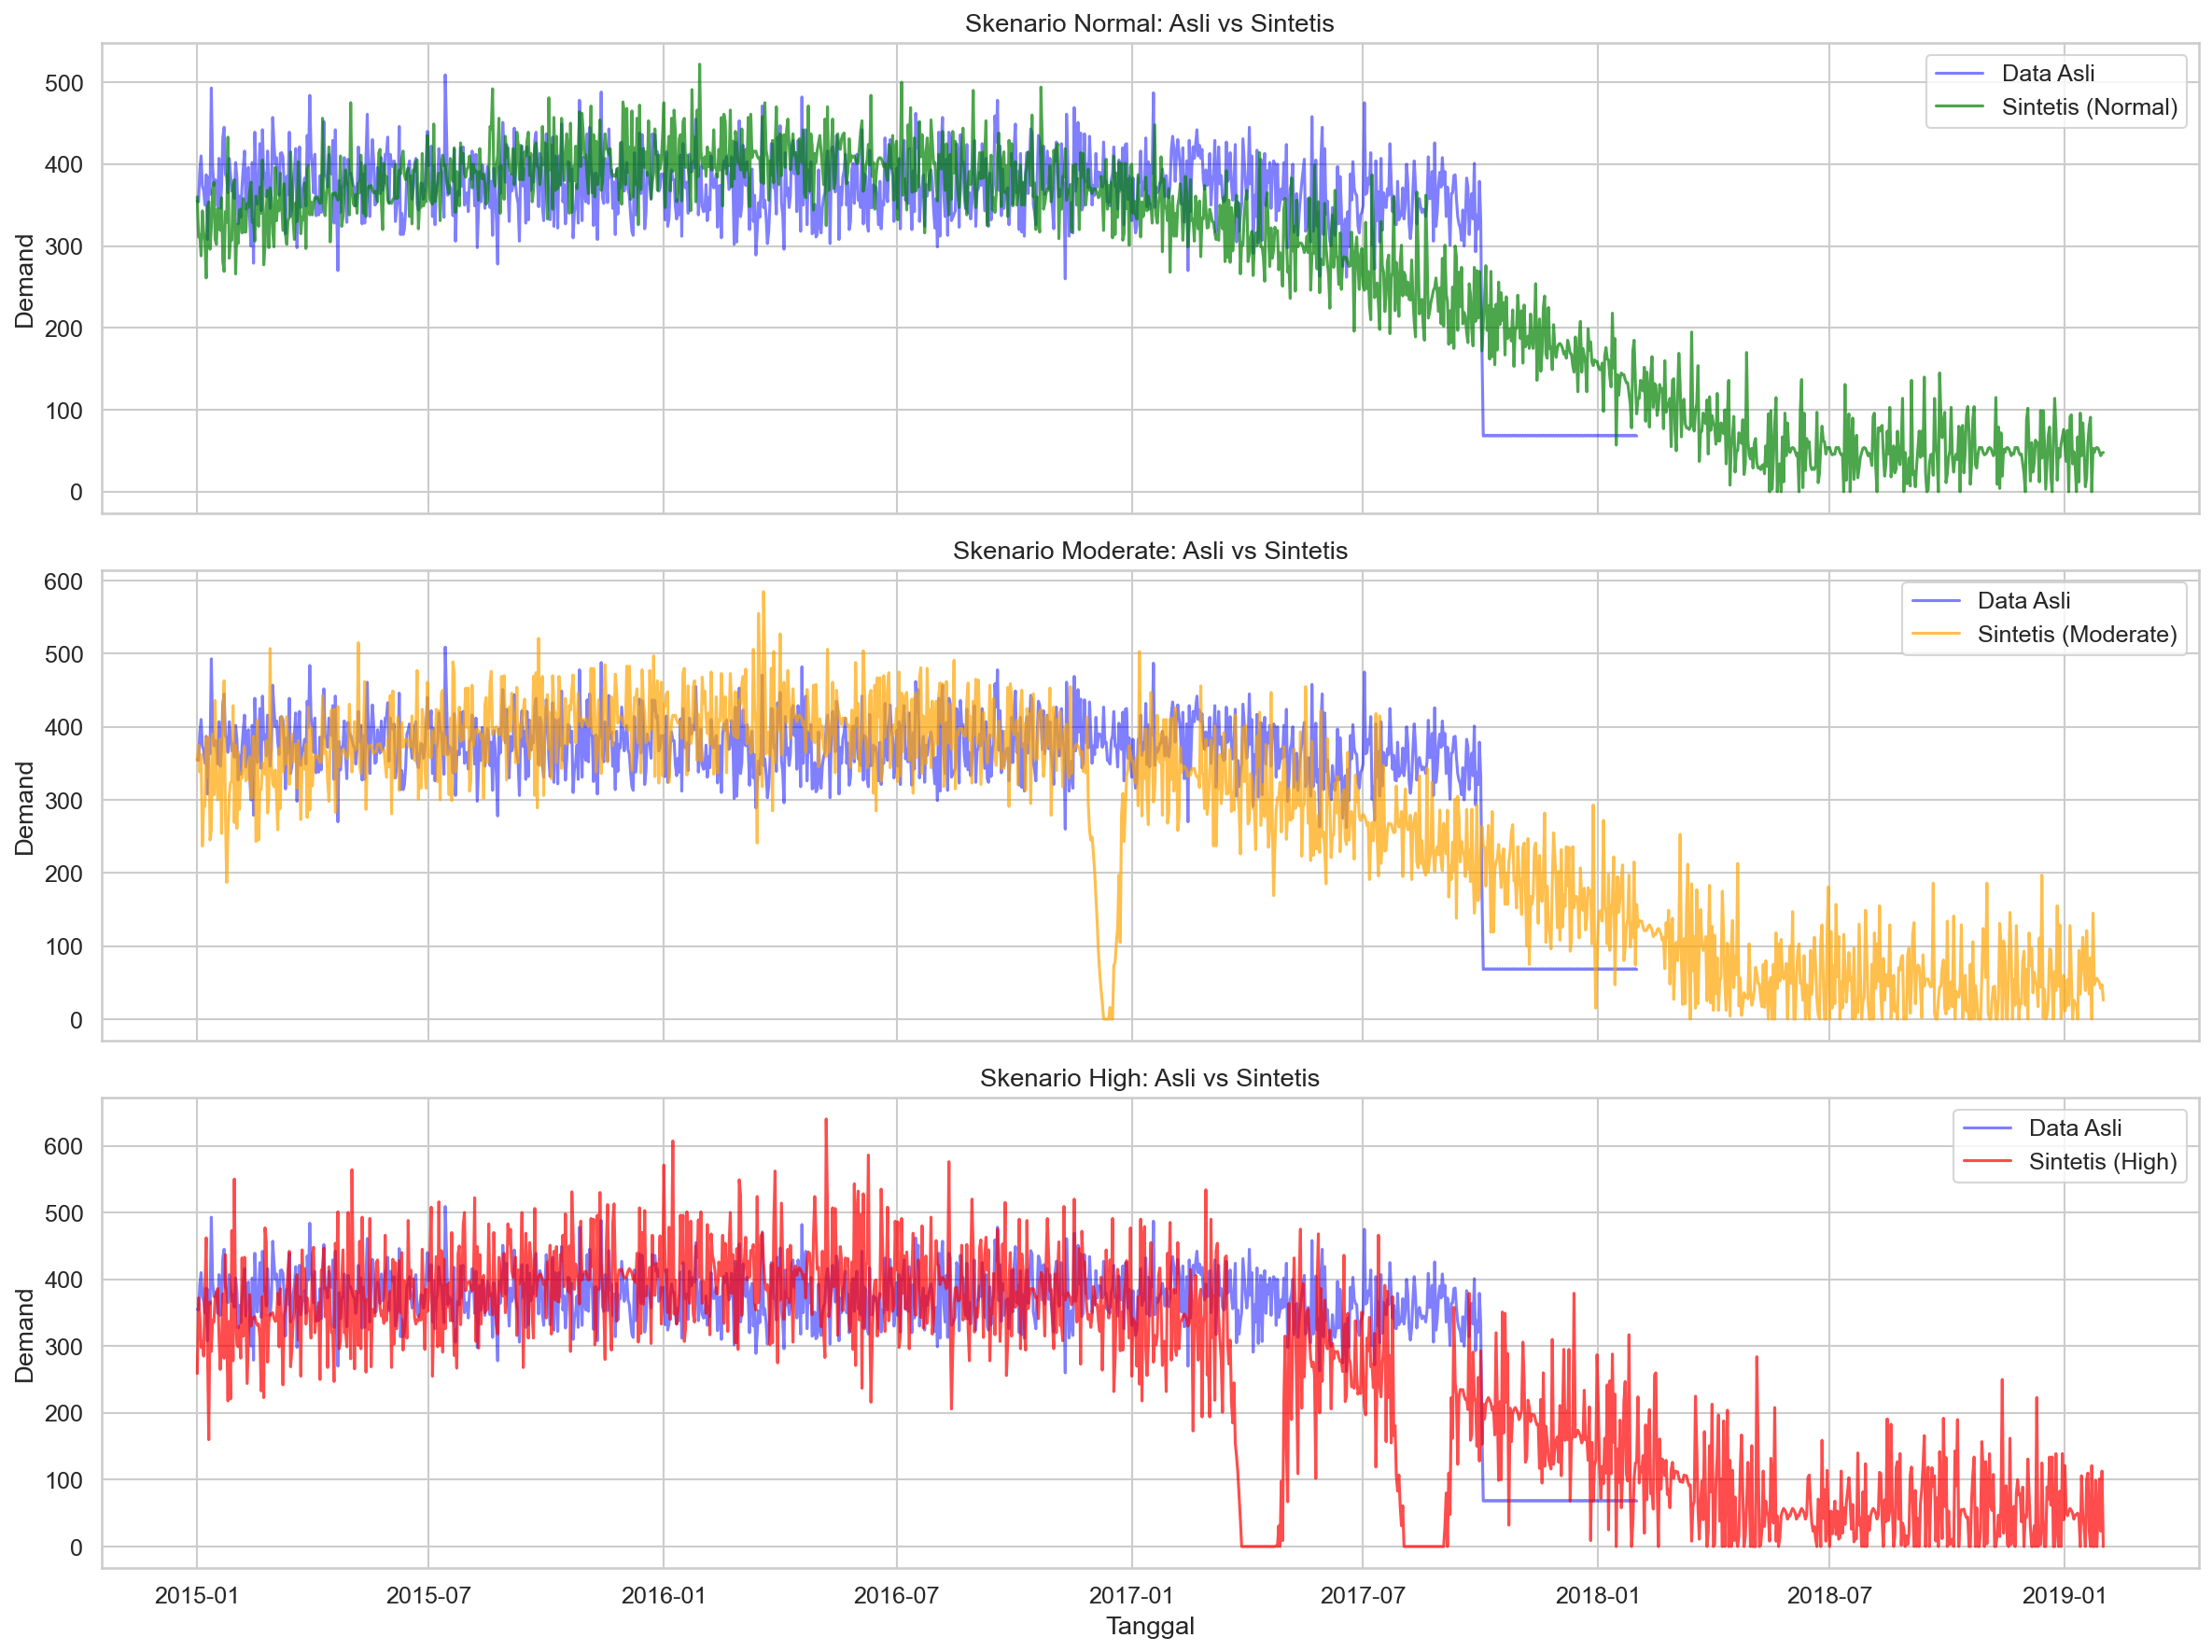

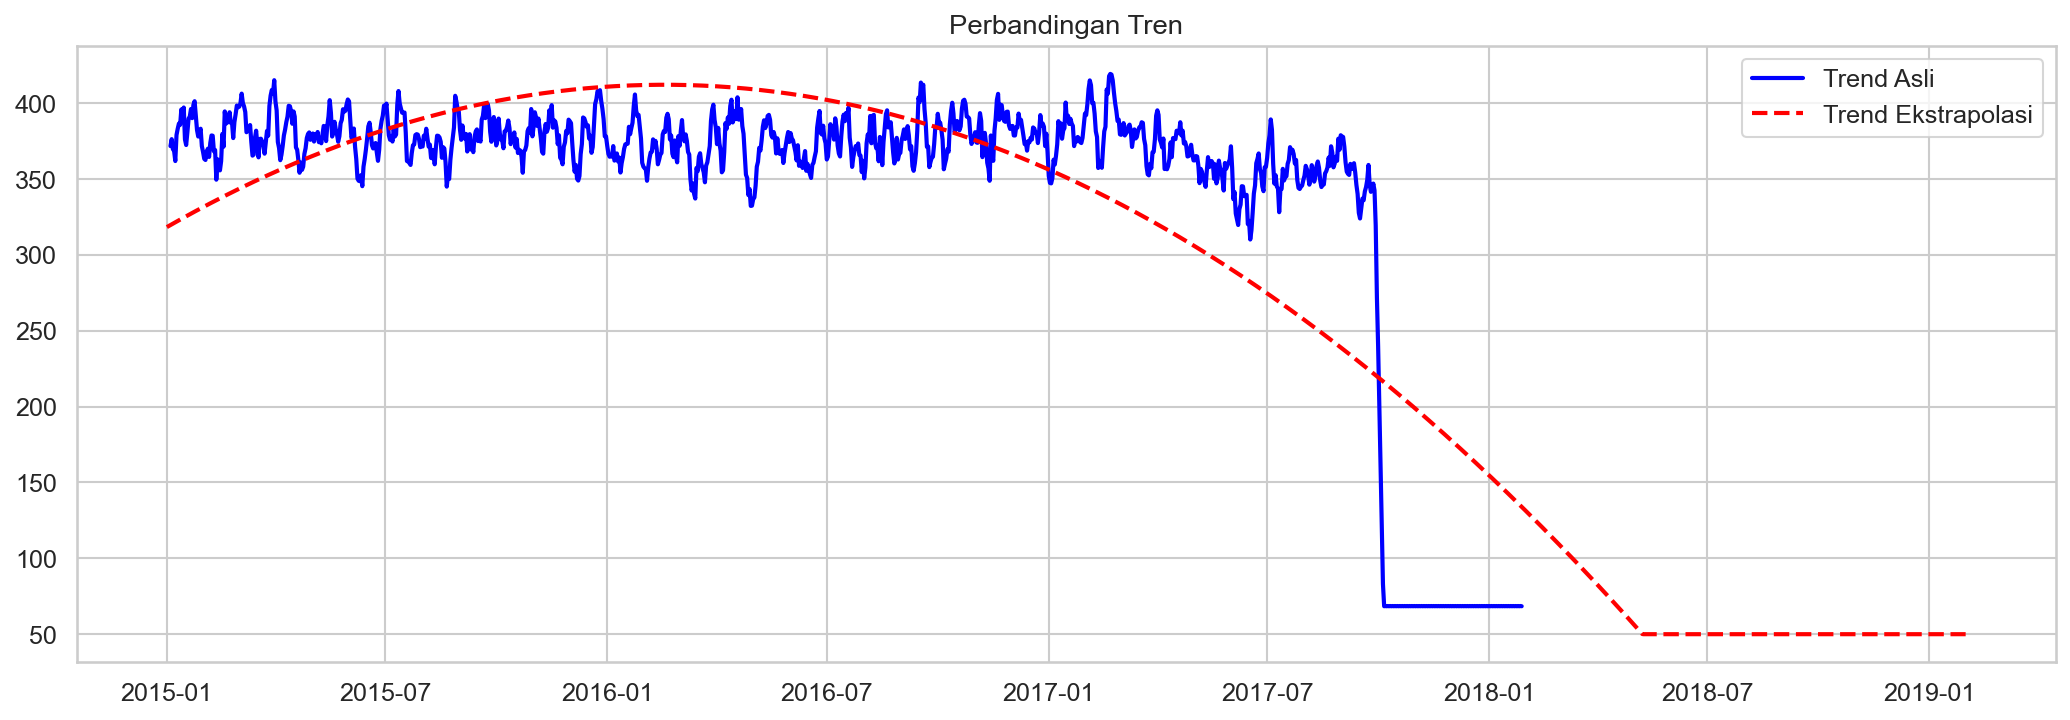

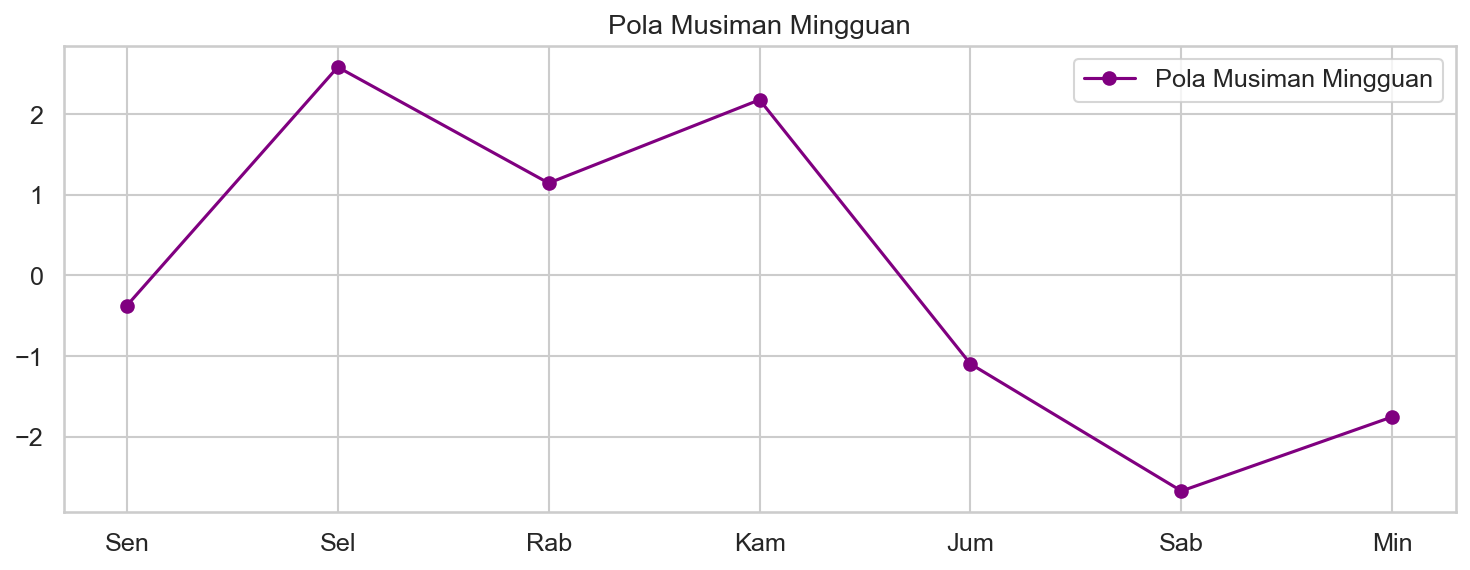

In [19]:
# 1. Original vs Synthetic Demand (All Scenarios)
fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)
colors = {'Normal': 'green', 'Moderate': 'orange', 'High': 'red'}

for i, (name, vals) in enumerate(scenarios.items()):
    axes[i].plot(daily.index, daily.values, alpha=0.5, color='blue', label='Data Asli')
    axes[i].plot(full_dates, vals, alpha=0.7, color=colors[name], label=f'Sintetis ({name})')
    axes[i].set_title(f'Skenario {name}: Asli vs Sintetis')
    axes[i].legend()
    axes[i].set_ylabel('Demand')

plt.xlabel('Tanggal')
plt.tight_layout()
plt.show()

# 2. Trend Comparison
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(trend_clean.index, trend_clean.values, label='Trend Asli', color='blue', linewidth=2)
ax.plot(full_dates, trend_full, label='Trend Ekstrapolasi', color='red', linestyle='--', linewidth=2)
ax.set_title('Perbandingan Tren')
ax.legend()
plt.tight_layout()
plt.show()

# 3. Seasonal Comparison
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(range(7), seasonal_pattern, 'o-', label='Pola Musiman Mingguan', color='purple')
ax.set_xticks(range(7))
ax.set_xticklabels(['Sen', 'Sel', 'Rab', 'Kam', 'Jum', 'Sab', 'Min'])
ax.set_title('Pola Musiman Mingguan')
ax.legend()
plt.tight_layout()
plt.show()

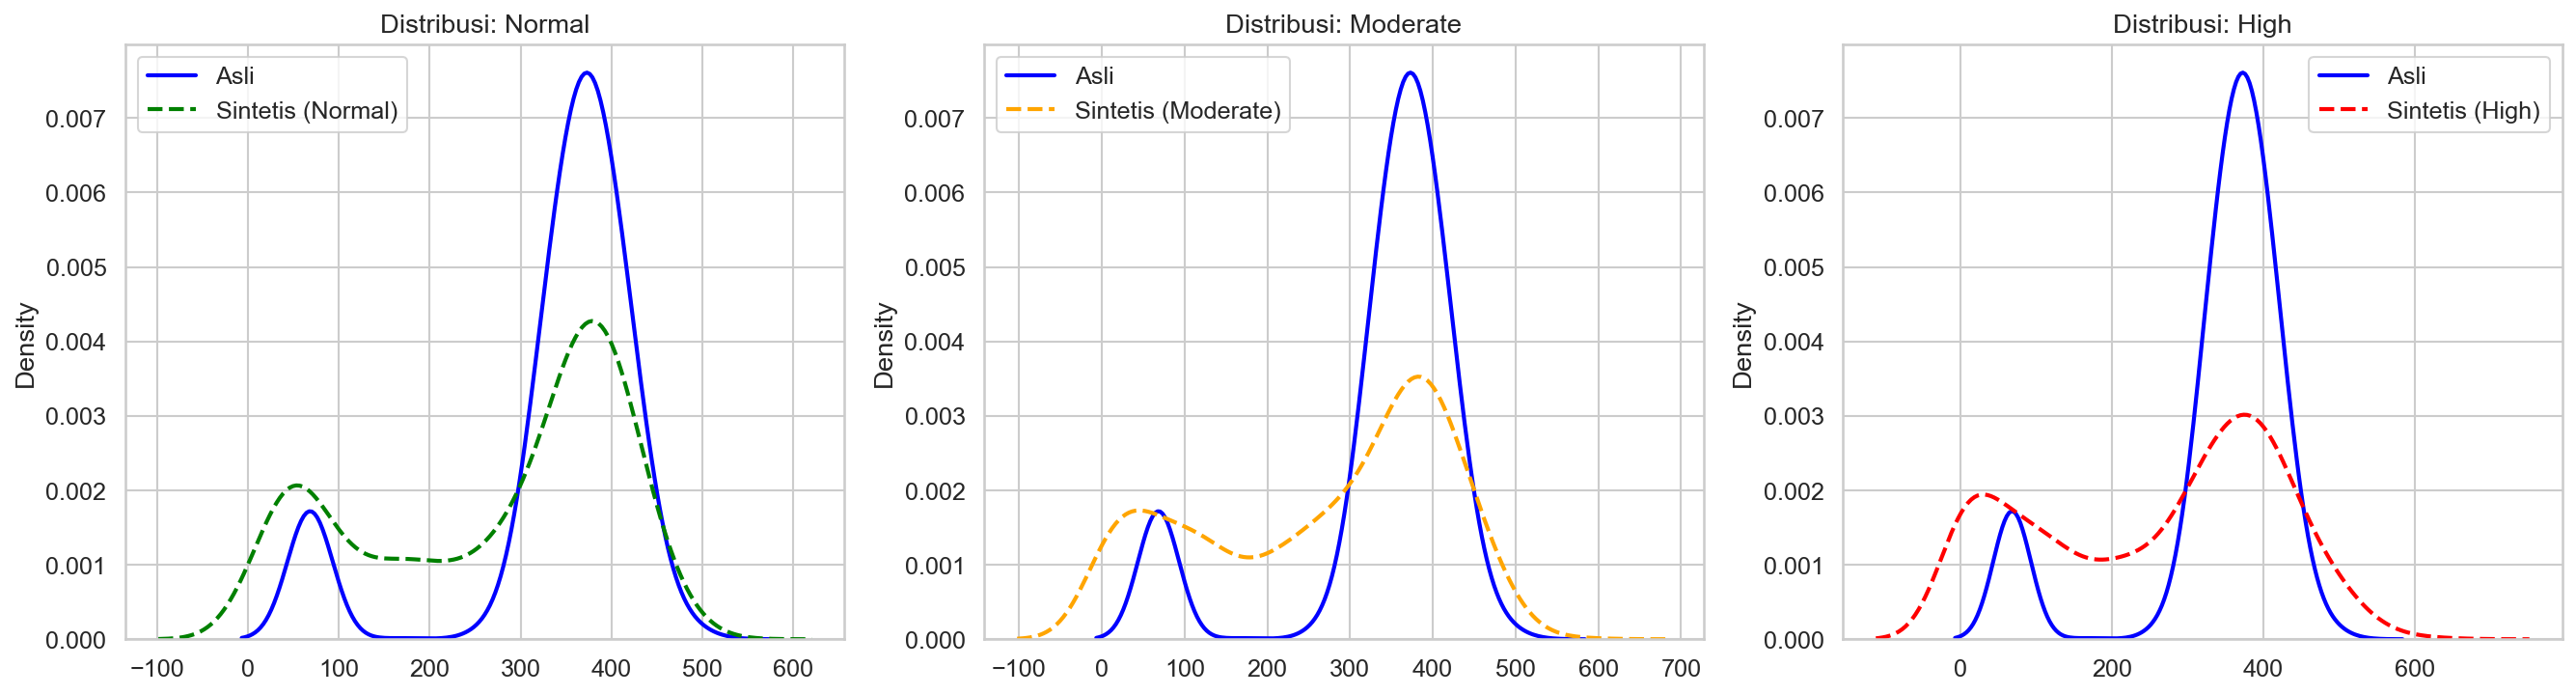

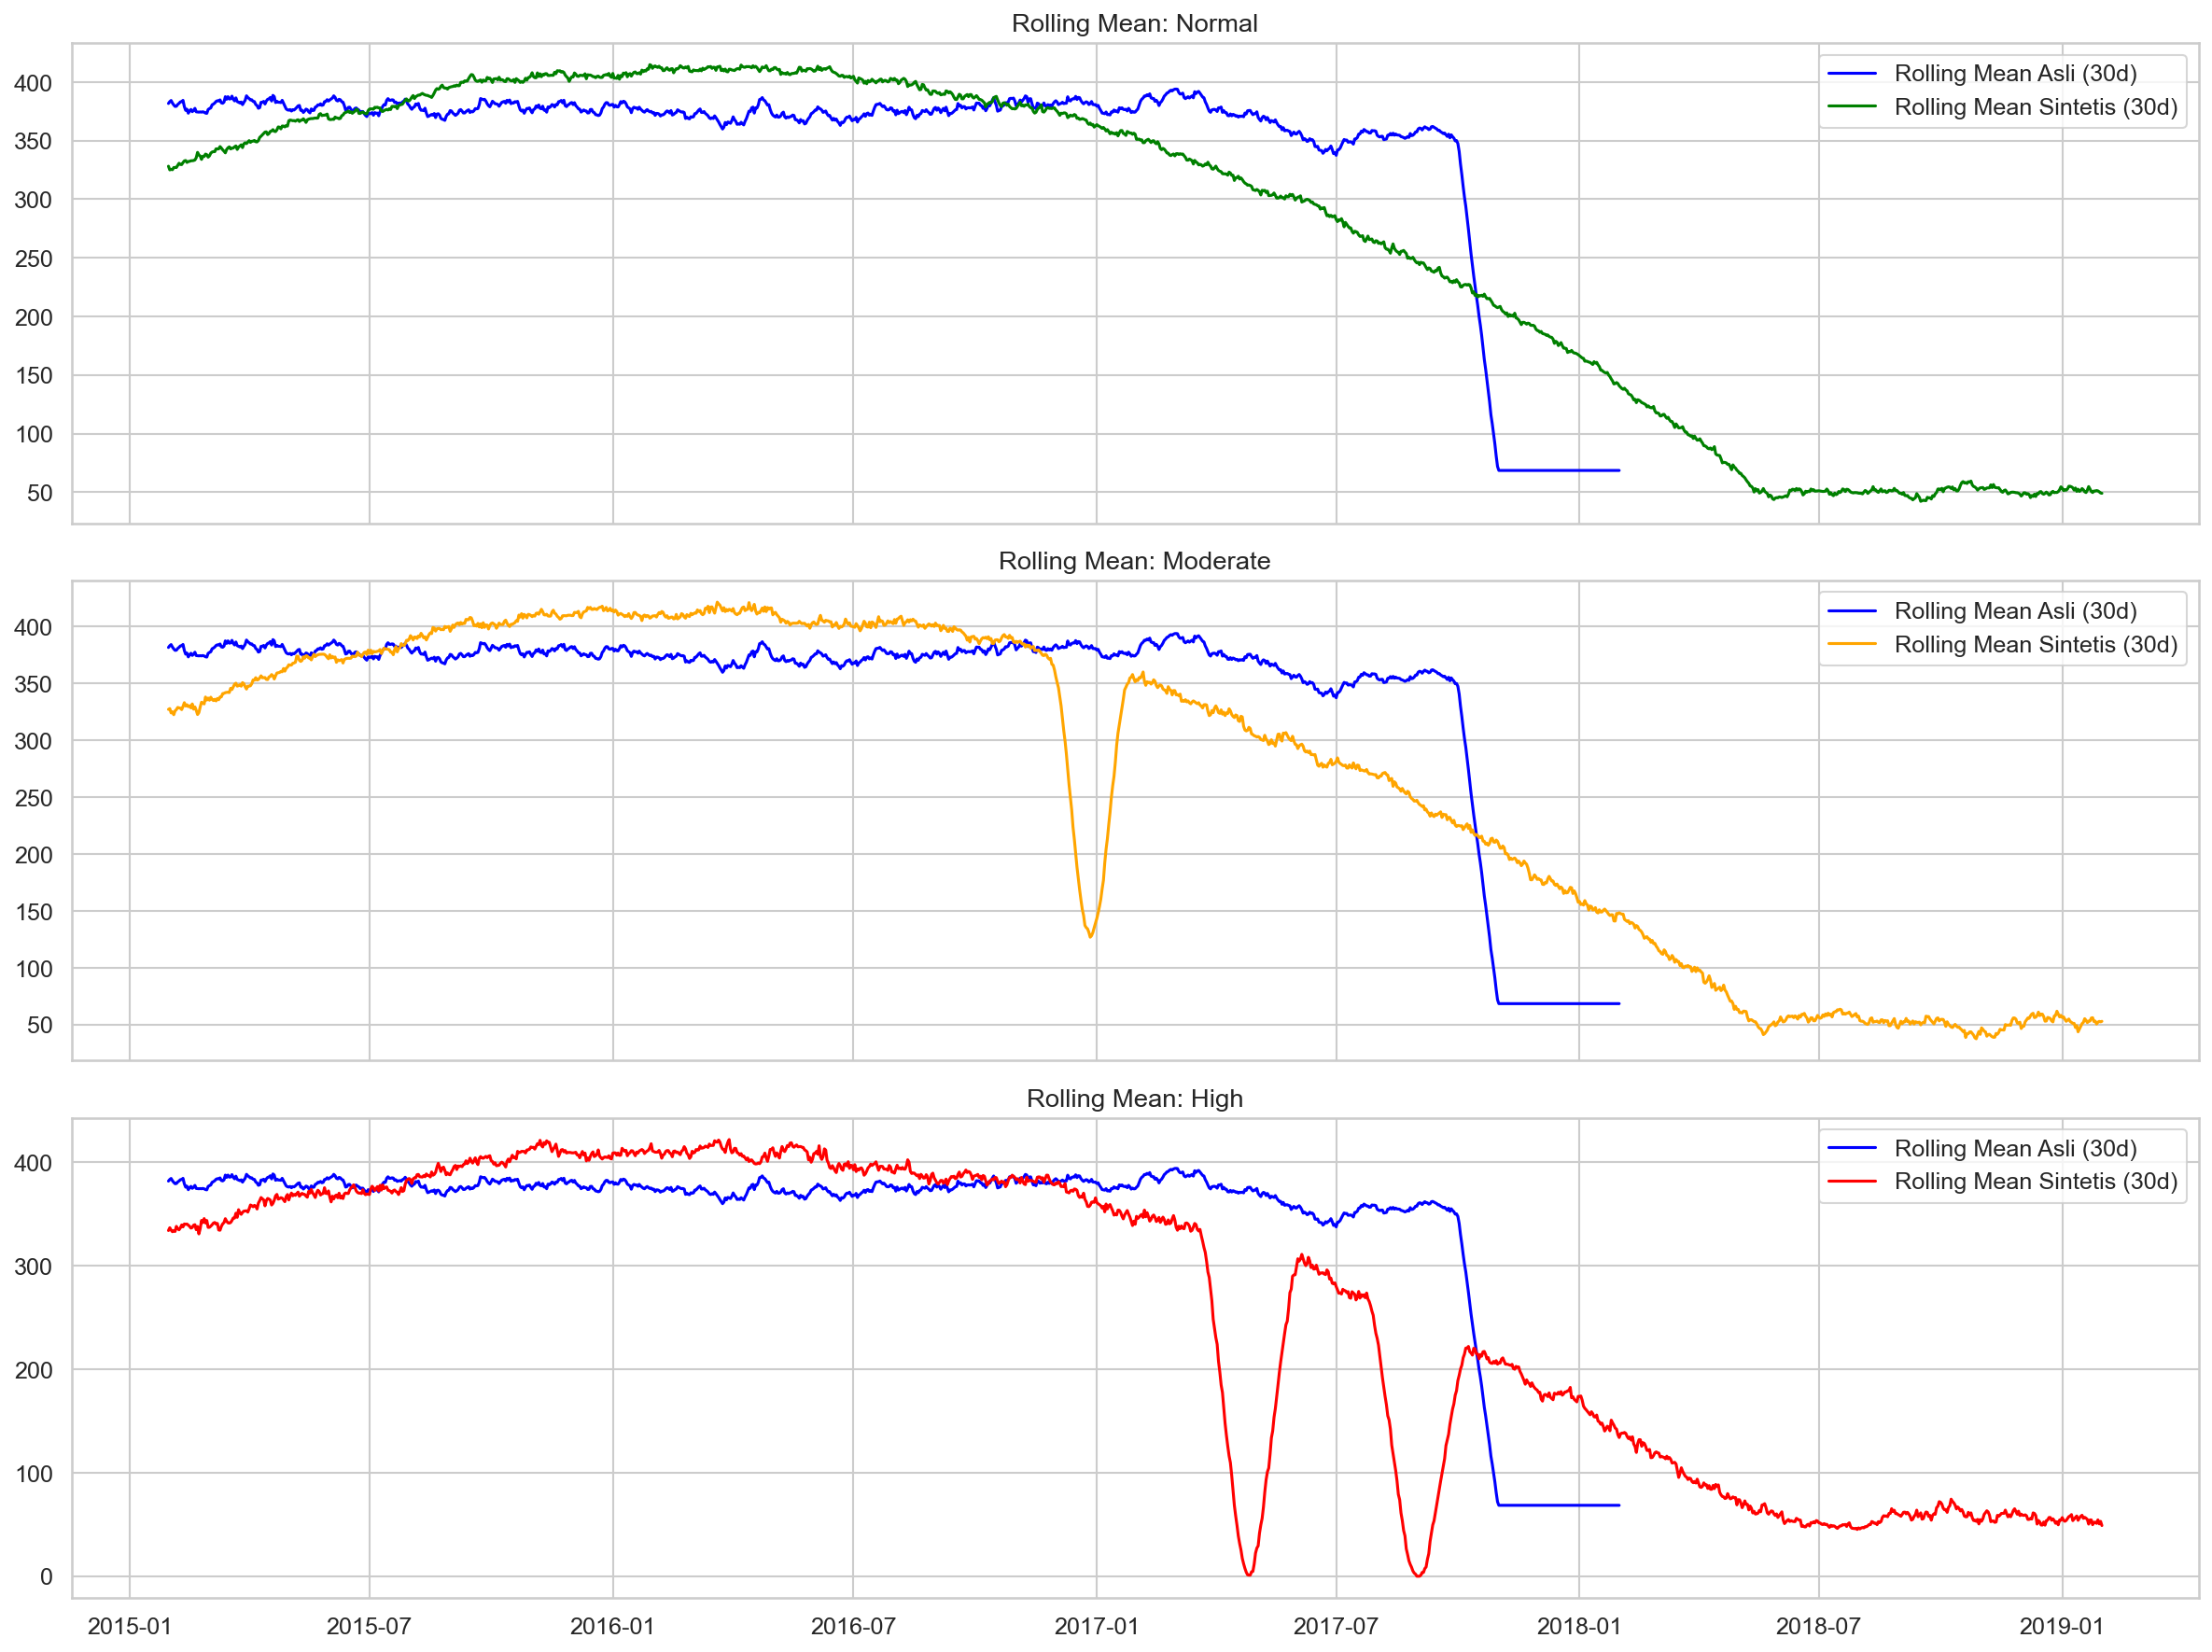

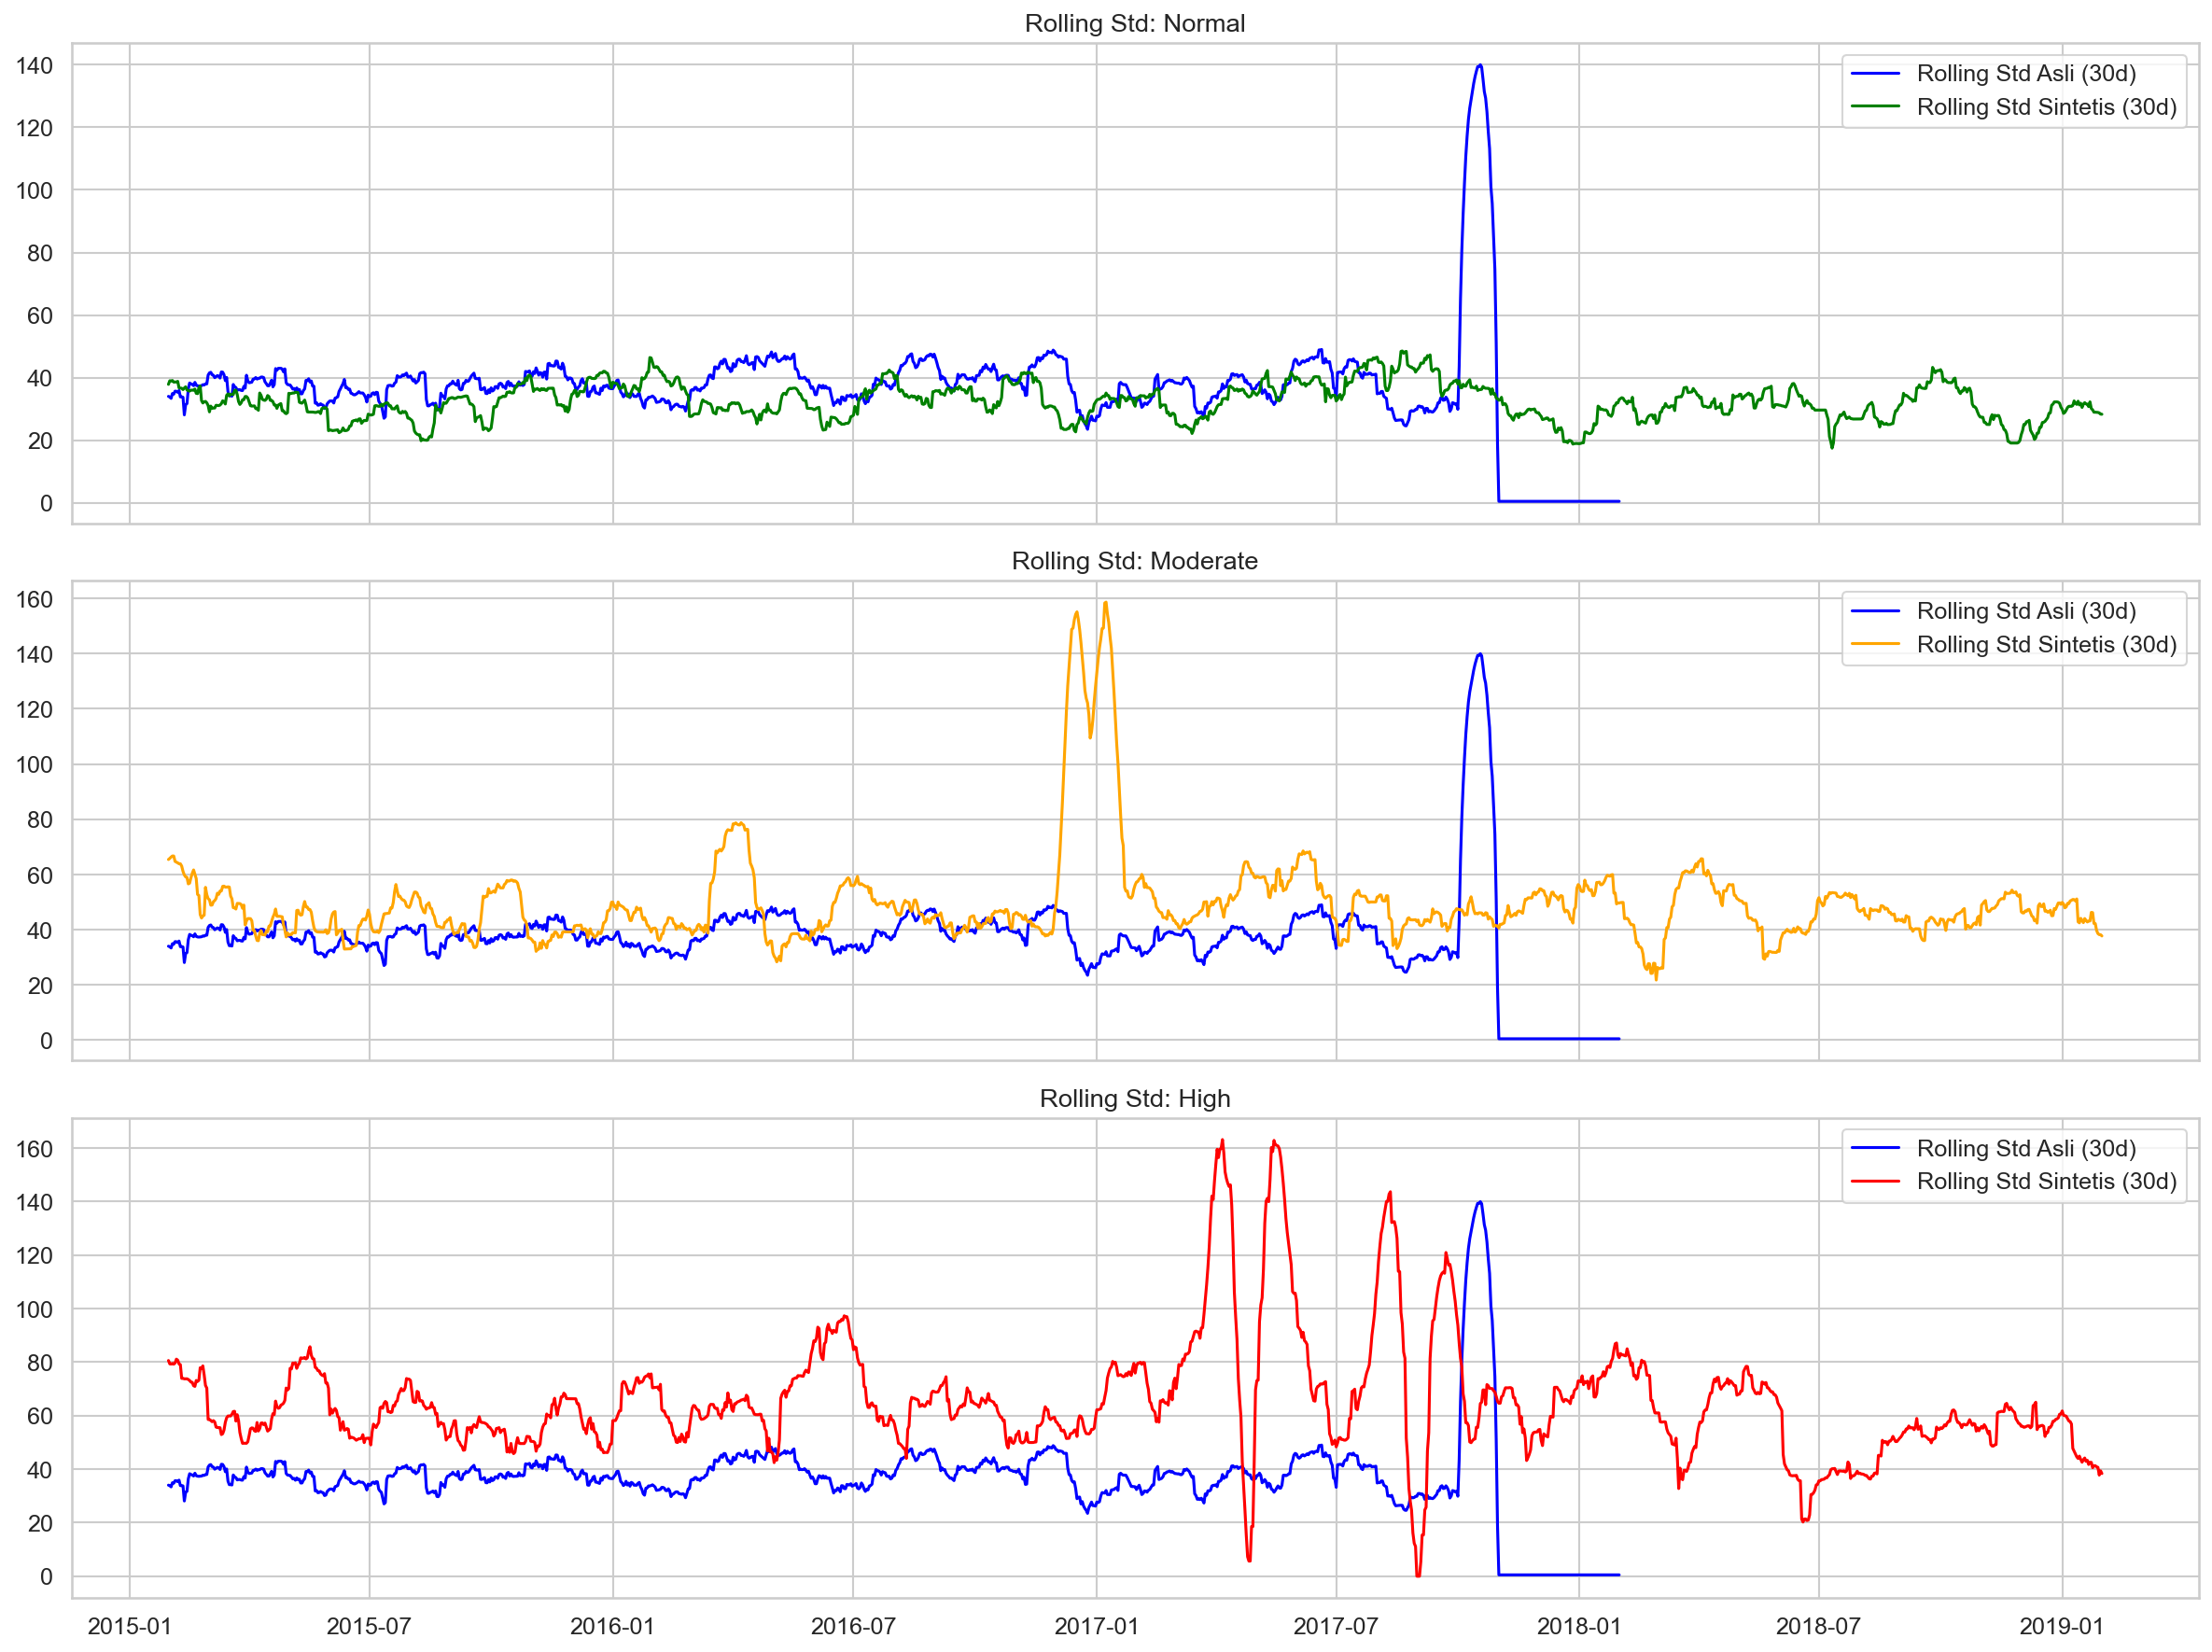

In [20]:
# 4. Distribution Comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, (name, vals) in enumerate(scenarios.items()):
    sns.kdeplot(daily.values, ax=axes[i], color='blue', label='Asli', linewidth=2)
    sns.kdeplot(vals, ax=axes[i], color=colors[name], label=f'Sintetis ({name})', linewidth=2, linestyle='--')
    axes[i].set_title(f'Distribusi: {name}')
    axes[i].legend()
plt.tight_layout()
plt.show()

# 5. Rolling Mean Comparison
fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)
window = 30
for i, (name, vals) in enumerate(scenarios.items()):
    orig_rolling = daily.rolling(window).mean()
    synth_series = pd.Series(vals, index=full_dates)
    synth_rolling = synth_series.rolling(window).mean()
    
    axes[i].plot(daily.index, orig_rolling, color='blue', label=f'Rolling Mean Asli ({window}d)')
    axes[i].plot(full_dates, synth_rolling, color=colors[name], label=f'Rolling Mean Sintetis ({window}d)')
    axes[i].set_title(f'Rolling Mean: {name}')
    axes[i].legend()
plt.tight_layout()
plt.show()

# 6. Rolling Std Comparison
fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)
for i, (name, vals) in enumerate(scenarios.items()):
    orig_std = daily.rolling(window).std()
    synth_series = pd.Series(vals, index=full_dates)
    synth_std = synth_series.rolling(window).std()
    
    axes[i].plot(daily.index, orig_std, color='blue', label=f'Rolling Std Asli ({window}d)')
    axes[i].plot(full_dates, synth_std, color=colors[name], label=f'Rolling Std Sintetis ({window}d)')
    axes[i].set_title(f'Rolling Std: {name}')
    axes[i].legend()
plt.tight_layout()
plt.show()

## Menyimpan Dataset Sintetis

In [21]:
filenames = {
    'Normal': 'normal_demand.csv',
    'Moderate': 'moderate_volatility.csv',
    'High': 'high_volatility.csv'
}

for name, vals in scenarios.items():
    df_out = pd.DataFrame({
        'order date (DateOrders)': full_dates,
        'Order Item Quantity': vals
    })
    
    path = f'data/generated_v2/{filenames[name]}'
    df_out.to_csv(path, index=False)
    print(f"Disimpan: {path} ({len(df_out)} baris)")

Disimpan: data/generated_v2/normal_demand.csv (1492 baris)
Disimpan: data/generated_v2/moderate_volatility.csv (1492 baris)
Disimpan: data/generated_v2/high_volatility.csv (1492 baris)


## Validasi Statistik (Statistical Validation)

In [22]:
from scipy.stats import skew, kurtosis, ks_2samp, wasserstein_distance

# Task 1: Statistical Validation
stats_list = []
# Include Original
stats_list.append({
    'Scenario': 'Original',
    'Mean': daily.mean(),
    'Std': daily.std(),
    'Min': daily.min(),
    'Max': daily.max(),
    'Skewness': skew(daily.dropna()),
    'Kurtosis': kurtosis(daily.dropna())
})

for name, vals in scenarios.items():
    stats_list.append({
        'Scenario': name,
        'Mean': np.mean(vals),
        'Std': np.std(vals),
        'Min': np.min(vals),
        'Max': np.max(vals),
        'Skewness': skew(vals),
        'Kurtosis': kurtosis(vals)
    })

df_stats = pd.DataFrame(stats_list)
display(df_stats.round(2))

,Scenario,Mean,Std,Min,Max,Skewness,Kurtosis
0,Original,340.80,101.54,68,509,-1.91,2.73
1,Normal,272.70,141.38,0,522,-0.57,-1.13
2,Moderate,268.86,147.18,0,585,-0.45,-1.12
3,High,258.75,159.89,0,640,-0.28,-1.23


## Kesamaan Distribusi (Distribution Similarity)

In [23]:
# Task 2: Distribution Similarity
dist_sim_list = []
orig_vals = daily.dropna().values

for name, vals in scenarios.items():
    ks_stat, ks_pval = ks_2samp(orig_vals, vals)
    w_dist = wasserstein_distance(orig_vals, vals)
    dist_sim_list.append({
        'Scenario': name,
        'KS Statistic': ks_stat,
        'KS p-value': ks_pval,
        'Wasserstein Distance': w_dist
    })

df_dist_sim = pd.DataFrame(dist_sim_list)
display(df_dist_sim.round(4))

print("Interpretasi:")
print("- KS Statistic mengukur jarak maksimum antara CDF empiris. Semakin kecil semakin mirip.")
print("- Wasserstein Distance (Earth Mover's Distance) mengukur 'biaya' untuk mengubah satu distribusi ke distribusi lain.")

,Scenario,KS Statistic,KS p-value,Wasserstein Distance
0,Normal,0.3108,0.0,68.7560
1,Moderate,0.3527,0.0,76.7280
2,High,0.3690,0.0,92.6803


Interpretasi:
- KS Statistic mengukur jarak maksimum antara CDF empiris. Semakin kecil semakin mirip.
- Wasserstein Distance (Earth Mover's Distance) mengukur 'biaya' untuk mengubah satu distribusi ke distribusi lain.


## Validasi Deret Waktu (Time-Series Validation)

In [24]:
# Task 3: Time-Series Validation (Trend & Seasonal Strength)
ts_val_list = []

def compute_strengths(ts_values, period=7):
    # decompose
    decomp = seasonal_decompose(pd.Series(ts_values), model='additive', period=period)
    T = decomp.trend.dropna()
    S = decomp.seasonal.dropna()
    R = decomp.resid.dropna()
    
    var_R = np.var(R)
    var_TR = np.var(T + R)
    var_SR = np.var(S + R)
    
    trend_strength = max(0, 1 - var_R / var_TR) if var_TR > 0 else 0
    seasonal_strength = max(0, 1 - var_R / var_SR) if var_SR > 0 else 0
    return trend_strength, seasonal_strength

# Original
t_str_orig, s_str_orig = compute_strengths(daily.values)
ts_val_list.append({
    'Scenario': 'Original',
    'Trend Strength': t_str_orig,
    'Seasonal Strength': s_str_orig
})

for name, vals in scenarios.items():
    t_str, s_str = compute_strengths(vals)
    ts_val_list.append({
        'Scenario': name,
        'Trend Strength': t_str,
        'Seasonal Strength': s_str
    })

df_ts_val = pd.DataFrame(ts_val_list)
display(df_ts_val.round(4))

print("Interpretasi:")
print("- Trend Strength & Seasonal Strength mendekati 1 berarti komponen tersebut sangat dominan.")
print("- Data sintetis diharapkan mempertahankan kekuatan musiman yang setara dengan data asli.")

,Scenario,Trend Strength,Seasonal Strength
0,Original,0.8918,0.0032
1,Normal,0.9476,0.0092
2,Moderate,0.8991,0.0032
3,High,0.8501,0.0039


Interpretasi:
- Trend Strength & Seasonal Strength mendekati 1 berarti komponen tersebut sangat dominan.
- Data sintetis diharapkan mempertahankan kekuatan musiman yang setara dengan data asli.


## Ekspor Ringkasan Validasi

In [25]:
# Gabungkan semua metrik validasi
df_final_val = df_stats.merge(df_dist_sim, on='Scenario', how='left').merge(df_ts_val, on='Scenario', how='left')

df_final_val.to_csv('data/generated_v2/synthetic_validation_summary.csv', index=False)
display(df_final_val.round(3))
print("\nRingkasan validasi disimpan ke: data/generated_v2/synthetic_validation_summary.csv")

,Scenario,Mean,Std,Min,Max,Skewness,Kurtosis,KS Statistic,KS p-value,Wasserstein Distance,Trend Strength,Seasonal Strength
0,Original,340.798,101.538,68,509,-1.915,2.726,NaN,NaN,NaN,0.892,0.003
1,Normal,272.700,141.383,0,522,-0.571,-1.130,0.311,0.0,68.756,0.948,0.009
2,Moderate,268.856,147.185,0,585,-0.454,-1.124,0.353,0.0,76.728,0.899,0.003
3,High,258.749,159.892,0,640,-0.280,-1.232,0.369,0.0,92.680,0.850,0.004



Ringkasan validasi disimpan ke: data/generated_v2/synthetic_validation_summary.csv
